Let's get the data from [FMI Weather](https://en.ilmatieteenlaitos.fi/observation-stations)

This is just a proof of concept that this can work

In [1]:
#!pip install fmiopendata

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
from fmiopendata.wfs import download_stored_query
import requests
import matplotlib.pyplot as plt


plt.style.use('ggplot')

## Dataset


In [3]:
df_raw = pd.read_csv("updated_weather_2y.csv", parse_dates=["time"])
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 201676 entries, 0 to 201675
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   time                    201676 non-null  datetime64[us]
 1   city                    201676 non-null  str           
 2   station_name            201676 non-null  str           
 3   fmisid                  201676 non-null  int64         
 4   lat                     201676 non-null  float64       
 5   lon                     201676 non-null  float64       
 6   temp                    201605 non-null  float64       
 7   highest_temperature     201628 non-null  float64       
 8   lowest_temperature      201631 non-null  float64       
 9   humidity                200546 non-null  float64       
 10  wind_speed              160035 non-null  float64       
 11  wind_speed_max          159242 non-null  float64       
 12  wind_dir                159281 non-null  

In [4]:
df_raw["u_wind"] = df_raw["wind_speed"] * np.sin(np.radians(df_raw["wind_dir"]))
df_raw["v_wind"] = df_raw["wind_speed"] * np.cos(np.radians(df_raw["wind_dir"]))

df_raw = df_raw.sort_values(["city", "time", "fmisid"])


agg_dict = {
    # Location
    "lat":                    "first",
    "lon":                    "first",
    # Temperature
    "temp":                   "mean",
    "highest_temperature":    "max",
    "lowest_temperature":     "min",
    # Atmospheric
    "humidity":               "mean",
    "pressure_sea":           "mean",
    # Wind
    "wind_speed":             "mean",
    "wind_speed_max":         "max",
    "greatest_gust_speed":    "max",
    "u_wind":                 "mean",
    "v_wind":                 "mean",
    # Precipitation
    "precip_1h":              "max",
    "snow_depth":             "mean",   
    "cloud_cover":            "mean",
    "present_weather_(auto)": "first",
    "dew_point":              "mean"
}

# Guard — only aggregate columns that actually exist
agg_dict = {k: v for k, v in agg_dict.items() if k in df_raw.columns}

df_city = (
    df_raw
    .groupby(["city", "time"])
    .agg(agg_dict)
    .reset_index()
)

# df_city["wind_dir"] = np.degrees(np.arctan2(df_city["u_wind"], df_city["v_wind"])) % 360




In [5]:
df_city.isnull().sum()

city                         0
time                         0
lat                          0
lon                          0
temp                         8
highest_temperature          8
lowest_temperature           8
humidity                    11
pressure_sea                15
wind_speed                 686
wind_speed_max             702
greatest_gust_speed        655
u_wind                    1005
v_wind                    1005
precip_1h                  122
snow_depth                 356
cloud_cover                 41
present_weather_(auto)      52
dew_point                    0
dtype: int64

In [6]:
# Check if nulls are concentrated in specific cities or time periods
print("Nulls per city:")
print(df_city.groupby("city")[["wind_speed", "u_wind", "v_wind", 
                                "precip_1h", "greatest_gust_speed"]].apply(
    lambda x: x.isnull().sum()
))

print("\nWind nulls")
wind_null_mask = df_city["u_wind"].isnull()
print(df_city[wind_null_mask][["city", "time"]].groupby("city").agg(["count", "min", "max"]))

print("\nPrecipitation nulls:")
precip_null_mask = df_city["precip_1h"].isnull()
print(df_city[precip_null_mask][["city", "time"]].groupby("city").agg(["count", "min", "max"]))

Nulls per city:
           wind_speed  u_wind  v_wind  precip_1h  greatest_gust_speed
city                                                                 
Helsinki            8       8       8          5                    8
Oulu               49      49      49         98                   49
Rovaniemi           0       0       0          0                    0
Tampere            23      23      23         10                   23
Turku             606     924     924          2                  575
Vaasa               0       1       1          7                    0

Wind nulls
          time                                        
         count                 min                 max
city                                                  
Helsinki     8 2024-04-26 14:00:00 2026-02-18 11:00:00
Oulu        49 2024-06-12 04:00:00 2025-12-03 22:00:00
Tampere     23 2023-12-05 10:00:00 2025-05-13 12:00:00
Turku      924 2023-11-18 23:00:00 2026-03-01 18:00:00
Vaasa        1 2024-12-04 1

In [7]:
cols_ffill = [
    "temp", "highest_temperature", "lowest_temperature",
    "humidity", "pressure_sea", "present_weather_(auto)"
]

df_city[cols_ffill] = (
    df_city.groupby("city")[cols_ffill]
    .ffill().bfill()
)

# Turku wind 
# fill with city-level median (neutral, non-fabricated)
wind_cols = ["wind_speed", "wind_speed_max", "greatest_gust_speed", "u_wind", "v_wind"]
for col in wind_cols:
    city_medians = df_city.groupby("city")[col].transform("median")
    df_city[col] = df_city[col].fillna(city_medians)


# No precip report from an AWS = no precipitation recorded
df_city["precip_1h"] = df_city["precip_1h"].fillna(0)

# Check again
df_city.isnull().sum()

city                        0
time                        0
lat                         0
lon                         0
temp                        0
highest_temperature         0
lowest_temperature          0
humidity                    0
pressure_sea                0
wind_speed                  0
wind_speed_max              0
greatest_gust_speed         0
u_wind                      0
v_wind                      0
precip_1h                   0
snow_depth                356
cloud_cover                41
present_weather_(auto)      0
dew_point                   0
dtype: int64

In [8]:
# ffillt and bfill the rest
df_city[["snow_depth", "cloud_cover"]] = (
    df_city.groupby("city")[["snow_depth", "cloud_cover"]]
    .ffill().bfill()
)

print(df_city.isnull().sum())

city                      0
time                      0
lat                       0
lon                       0
temp                      0
highest_temperature       0
lowest_temperature        0
humidity                  0
pressure_sea              0
wind_speed                0
wind_speed_max            0
greatest_gust_speed       0
u_wind                    0
v_wind                    0
precip_1h                 0
snow_depth                0
cloud_cover               0
present_weather_(auto)    0
dew_point                 0
dtype: int64


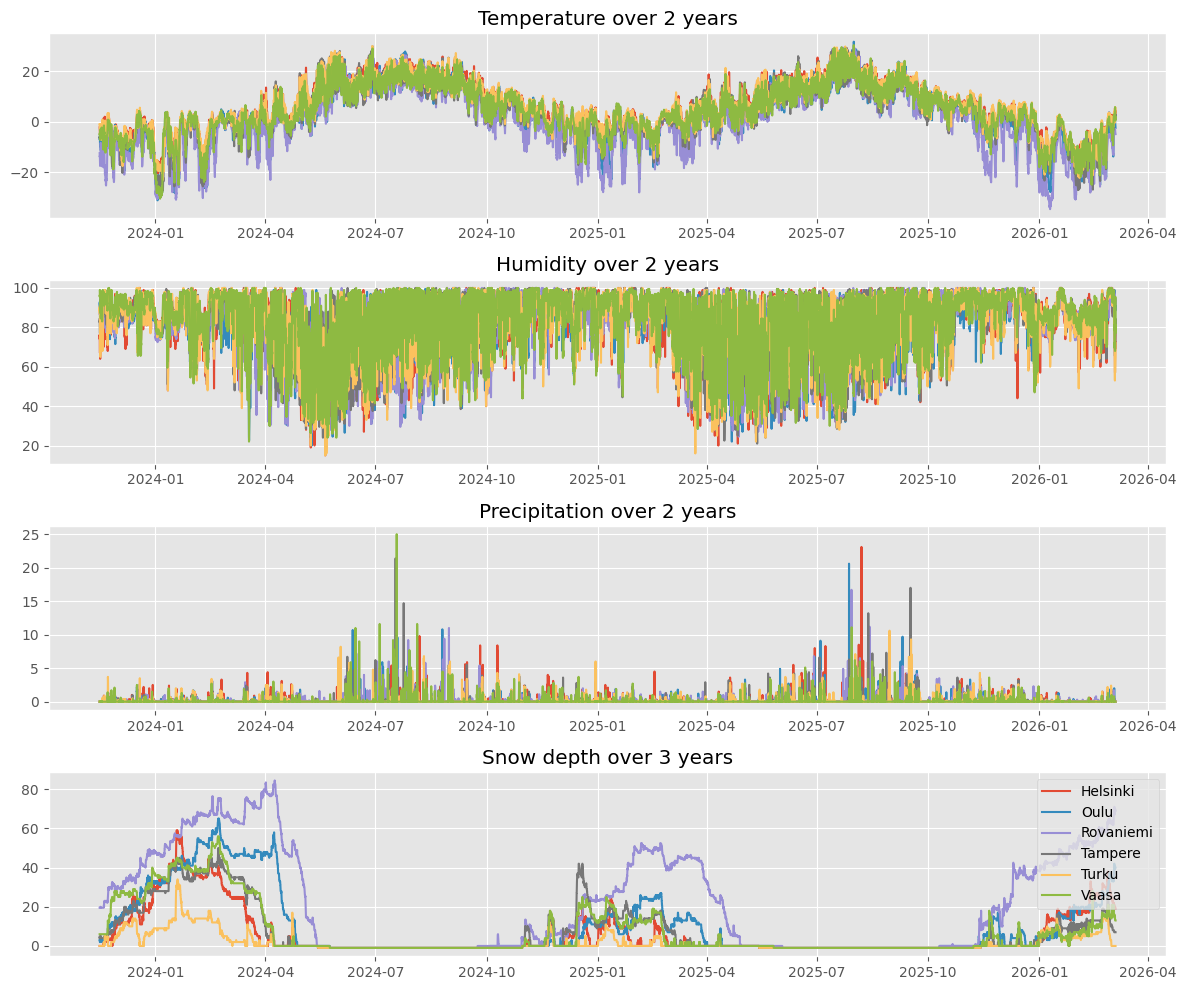

In [9]:
df = df_city.copy()
plt.figure(figsize= (12, 10))

plt.subplot(4, 1, 1)
for city in df['city'].unique():
    city_data = df[df['city'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['temp'], label = city)

plt.title("Temperature over 2 years")



plt.subplot(4, 1, 2)
for city in df['city'].unique():
    city_data = df[df['city'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['humidity'], label = city)
    
plt.title("Humidity over 2 years")


plt.subplot(4, 1, 3)
for city in df['city'].unique():
    city_data = df[df['city'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['precip_1h'], label = city)
    
plt.title("Precipitation over 2 years")


plt.subplot(4, 1, 4)
for city in df['city'].unique():
    city_data = df[df['city'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['snow_depth'], label = city)

plt.title("Snow depth over 3 years")
plt.legend()


plt.tight_layout()
plt.show()

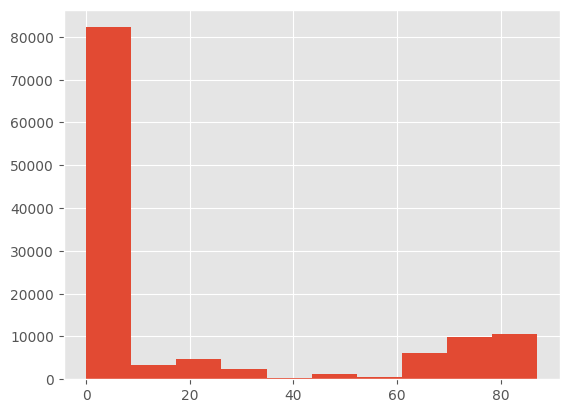

In [10]:
df['present_weather_(auto)'].hist()
plt.show()

code
0    92649
2    20565
1     7712
Name: count, dtype: int64

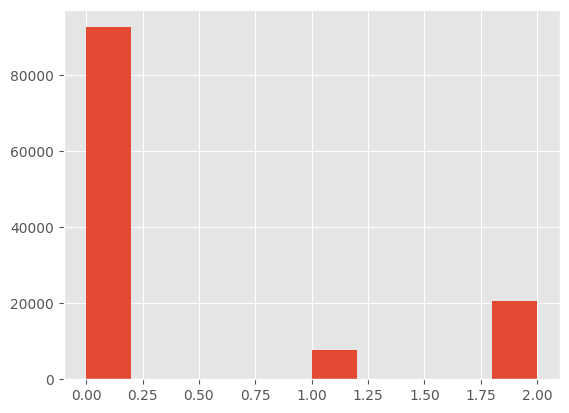

In [11]:
def map_weather_codes(code):
    if code <= 49:  return 0   # Clear / Fog / Mist
    elif code <= 69: return 1  # Rain / Drizzle
    elif code <= 89: return 2  # Snow / Sleet
    return 0

df['code'] = df['present_weather_(auto)'].apply(map_weather_codes)

df['code'].hist()
df['code'].value_counts()


In [12]:
df.groupby('city')['code'].value_counts().unstack()

code,0,1,2
city,,,
Helsinki,15073,1812,3265
Oulu,15867,853,3441
Rovaniemi,13955,1043,5163
Tampere,15336,1125,3700
Turku,16296,1468,2368
Vaasa,16122,1411,2628


In [13]:
df['pressure_change_1h'] = df.groupby('city')['pressure_sea'].diff(1)
df['pressure_change_3h'] = df.groupby('city')['pressure_sea'].diff(3)
df['pressure_change_6h'] = df.groupby('city')['pressure_sea'].diff(6)

df['dew_point_dep'] = df['temp'] - df['dew_point']
df['is_freezing'] = (df['temp'] <= 0).astype(int)

df['code_lag_1h'] = df.groupby('city')['code'].shift(1)
df['code_lag_3h'] = df.groupby('city')['code'].shift(3)
df['code_lag_6h'] = df.groupby('city')['code'].shift(6)

df['temp_lag_1h'] = df.groupby('city')['temp'].shift(1)
df['temp_lag_3h'] = df.groupby('city')['temp'].shift(3)
df['temp_lag_6h'] = df.groupby('city')['temp'].shift(6)


df['precip_lag_1h'] =  df.groupby('city')['precip_1h'].shift(1)
df['precip_lag_3h'] =  df.groupby('city')['precip_1h'].shift(3)
df['precip_lag_6h'] =  df.groupby('city')['precip_1h'].shift(6)

df['hour'] = df['time'].dt.hour
df['day']  = df['time'].dt.day_of_year

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 365.25)

target_col = []
target_mark = [3, 6, 12]
for col in target_mark:
    col_name = f'target_{col}h'
    df[col_name] = df.groupby('city')['code'].shift(-col)
    target_col.append(col_name)

df = df.dropna()

In [14]:
df.columns

Index(['city', 'time', 'lat', 'lon', 'temp', 'highest_temperature',
       'lowest_temperature', 'humidity', 'pressure_sea', 'wind_speed',
       'wind_speed_max', 'greatest_gust_speed', 'u_wind', 'v_wind',
       'precip_1h', 'snow_depth', 'cloud_cover', 'present_weather_(auto)',
       'dew_point', 'code', 'pressure_change_1h', 'pressure_change_3h',
       'pressure_change_6h', 'dew_point_dep', 'is_freezing', 'code_lag_1h',
       'code_lag_3h', 'code_lag_6h', 'temp_lag_1h', 'temp_lag_3h',
       'temp_lag_6h', 'precip_lag_1h', 'precip_lag_3h', 'precip_lag_6h',
       'hour', 'day', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'target_3h', 'target_6h', 'target_12h'],
      dtype='str')

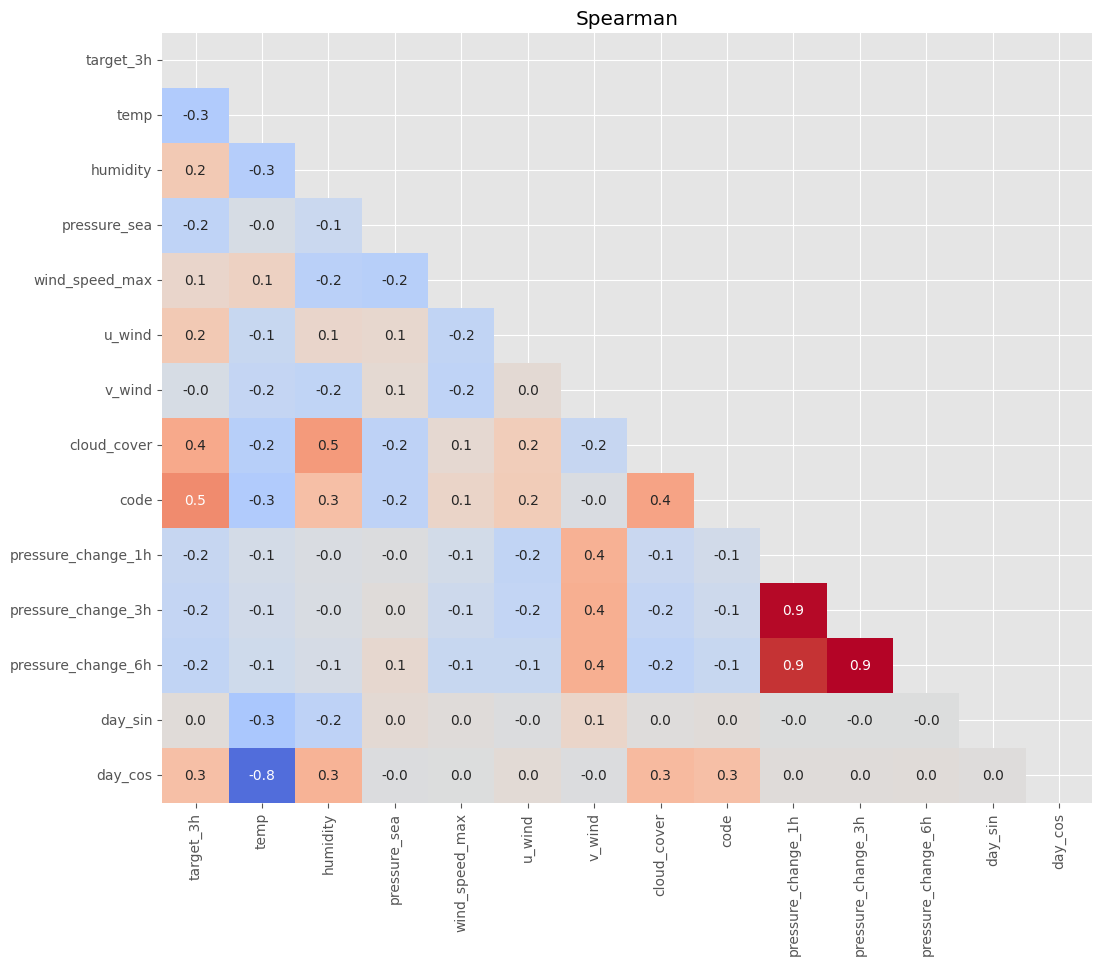

In [15]:
import seaborn as sns
feature = [
    # 'target_3h',
#    'lat', 'lon', 
   'temp', 
    # 'temp_lag_1h', 'temp_lag_3h',
    # 'temp_lag_6h',
#    'highest_temperature', 'lowest_temperature', 
   
   'humidity', 
   'pressure_sea', 
#    'wind_speed',
    'wind_speed_max', 
    # 'greatest_gust_speed', 
    'u_wind', 'v_wind',
    
    # 'precip_1h', 
    # 'precip_lag_1h', 'precip_lag_3h', 'precip_lag_6h',
    # 'snow_depth', 
    'cloud_cover',
    # 'dew_point', 
    'code', 
    # 'code_lag_1h', 
    # 'code_lag_3h', 'code_lag_6h',
    'pressure_change_1h', 
    'pressure_change_3h',
    'pressure_change_6h', 
    
    # 'dew_point_dep', 
    # 'is_freezing',
    # 'hour_sin', 'hour_cos', 
    'day_sin', 'day_cos',

]

matrix = df[['target_3h'] + feature].corr(method= 'spearman')

mask = np.triu(np.ones_like(matrix, dtype=bool))
plt.figure(figsize = (12, 10))
sns.heatmap(matrix, mask= mask, cmap = 'coolwarm', center = 0,
            cbar = False, annot= True, fmt = '.1f')
plt.title('Spearman')
plt.show()



In [16]:
train_list, val_list, test_list = [], [], []

# stratified split so that we have a balanced amount of data from each cities 
# within the train, val, test set
# for city in df['city'].unique():
#     city_df = df[df['city'] == city].sort_values('time')
    
#     n = len(city_df)
#     train_end = int(n * 0.70)
#     val_end = int(n * 0.85)
    
#     train_list.append(city_df.iloc[:train_end])
#     val_list.append(city_df.iloc[train_end:val_end])
#     test_list.append(city_df.iloc[val_end:])

# train_df = pd.concat(train_list)
# val_df = pd.concat(val_list)
# test_df = pd.concat(test_list)

train_df = df[df['time'] < '2024-11-01']                                                    # Nov 2023 → Oct 2024 (12 months)
val_df   = df[(df['time'] >= '2024-11-01') & (df['time'] < '2025-04-01')]                   # Nov 2024 → Mar 2025 (4 months, full winter)
test_df  = df[(df['time'] >= '2025-11-01')]                                                  # Nov 2025 → Mar 2026 (4 months, full winter)

# Verify
print(f"Train: {train_df['time'].min().date()} → {train_df['time'].max().date()} | {len(train_df):,} rows")
print(f"Val:   {val_df['time'].min().date()} → {val_df['time'].max().date()} | {len(val_df):,} rows")
print(f"Test:  {test_df['time'].min().date()} → {test_df['time'].max().date()} | {len(test_df):,} rows")
print(f"Gap:   Apr 2025 → Oct 2025 (7 months unused)")



X_val, X_test = val_df[feature], test_df[feature]
y_val, y_test = val_df[target_col].astype(int), test_df[target_col].astype(int)

print(train_df.shape, val_df.shape, test_df.shape)


Train: 2023-11-16 → 2024-10-31 | 50,497 rows
Val:   2024-11-01 → 2025-03-31 | 21,738 rows
Test:  2025-11-01 → 2026-03-04 | 17,782 rows
Gap:   Apr 2025 → Oct 2025 (7 months unused)
(50497, 43) (21738, 43) (17782, 43)


In [17]:
# Check how many rows of each city are in each split
for name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} Split:")
    print(split_df['city'].value_counts())


Train Split:
city
Oulu         8418
Rovaniemi    8418
Tampere      8418
Vaasa        8418
Turku        8414
Helsinki     8411
Name: count, dtype: int64

Val Split:
city
Helsinki     3624
Oulu         3624
Rovaniemi    3624
Tampere      3624
Vaasa        3624
Turku        3618
Name: count, dtype: int64

Test Split:
city
Helsinki     2965
Oulu         2965
Rovaniemi    2965
Tampere      2965
Vaasa        2965
Turku        2957
Name: count, dtype: int64


In [18]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

models = {}
val_predicts = {}

undersample_frac = 0.3

for col in target_col:
    print(f"Working on model for {col}\n")

    major = train_df[train_df[col] == 0]
    minor = train_df[train_df[col] != 0]

    undersample_major = major.sample(frac = undersample_frac, random_state = 8)

    train_balanced = pd.concat([undersample_major, minor]).sample(frac = 1, random_state = 8)

    X_train, y_train = train_balanced[feature], train_balanced[col].astype(int)

    model = LGBMClassifier(
        objective= 'multiclass',
        num_class = 3,
        class_weight= 'balanced',
        n_estimators= 2000,
        learning_rate= 0.05,
        random_state= 8
    )

    model.fit(X_train, y_train,
              eval_set= [(X_val, y_val[col])],
              callbacks= [
                  early_stopping(stopping_rounds = 50),
                  log_evaluation(200),
              ]
              )

    y_pred = model.predict(X_val)

    models[col] = model
    val_predicts[col] = y_pred

    print(f"Complete model for {col}\n\n")


Working on model for target_3h

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2777
[LightGBM] [Info] Number of data points in the train set: 23260, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[200]	valid_0's multi_logloss: 0.698312
[400]	valid_0's multi_logloss: 0.681086
[600]	valid_0's multi_logloss: 0.676031
Early stopping, best iteration is:
[558]	valid_0's multi_logloss: 0.67562
Complete model for target_3h


Working on model for target_6h

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000990 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2769
[Li

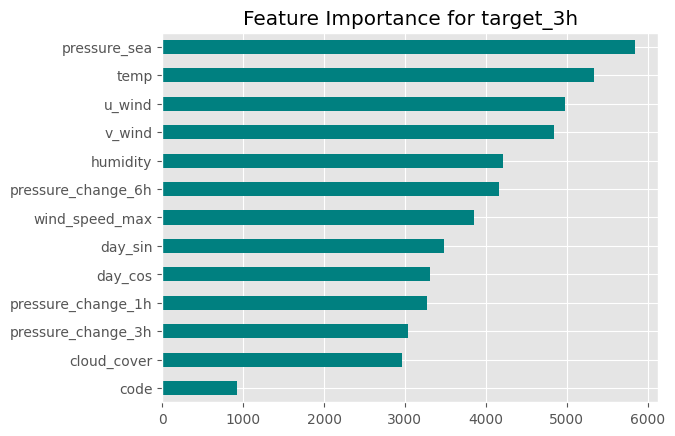

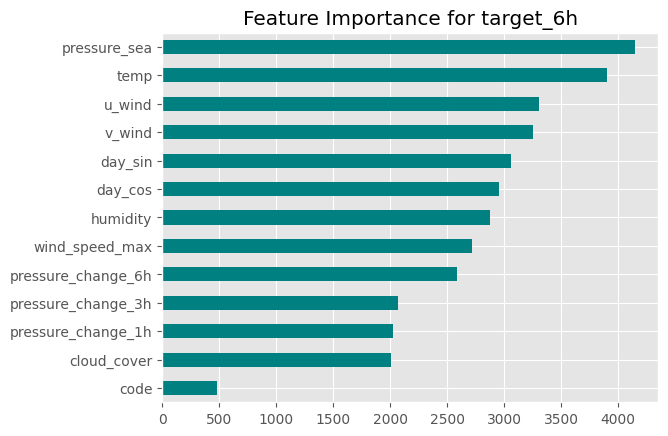

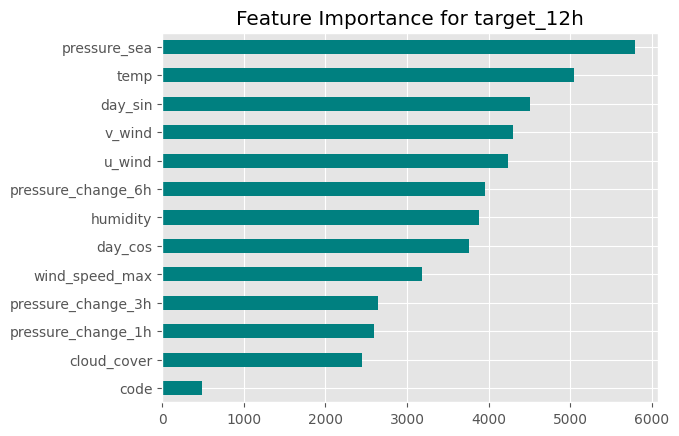

In [19]:


for col in target_col:
    # 1. Get the underlying booster from the XGBRegressor
    model = models[col]
    
    
    feat_imp = pd.Series(model.feature_importances_, index = feature).sort_values()
    feat_imp.plot(kind = 'barh', color = "teal")
    plt.title(f"Feature Importance for {col}")
    plt.show()

Classification report for model_target_3h
              precision    recall  f1-score   support

    Clear(0)       0.90      0.73      0.81     16030
    Rain (1)       0.27      0.47      0.35      1330
    Snow (2)       0.46      0.69      0.55      4378

    accuracy                           0.70     21738
   macro avg       0.55      0.63      0.57     21738
weighted avg       0.78      0.70      0.73     21738



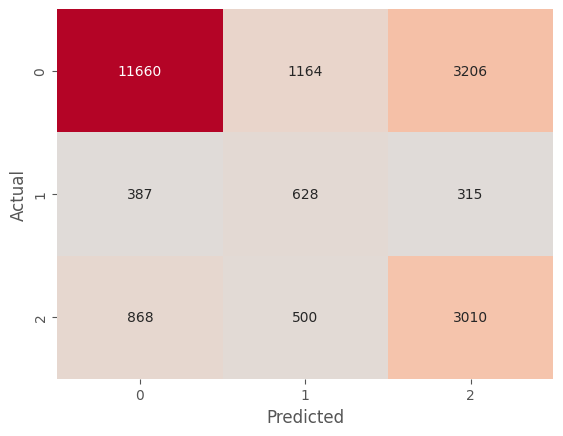

Classification report for model_target_6h
              precision    recall  f1-score   support

    Clear(0)       0.89      0.63      0.74     16039
    Rain (1)       0.20      0.42      0.27      1324
    Snow (2)       0.40      0.69      0.51      4375

    accuracy                           0.63     21738
   macro avg       0.50      0.58      0.51     21738
weighted avg       0.75      0.63      0.66     21738



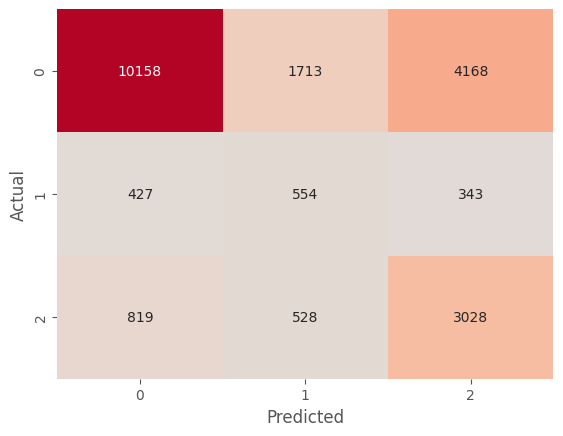

Classification report for model_target_12h
              precision    recall  f1-score   support

    Clear(0)       0.85      0.54      0.66     16055
    Rain (1)       0.13      0.25      0.17      1317
    Snow (2)       0.33      0.69      0.45      4366

    accuracy                           0.55     21738
   macro avg       0.44      0.49      0.42     21738
weighted avg       0.71      0.55      0.59     21738



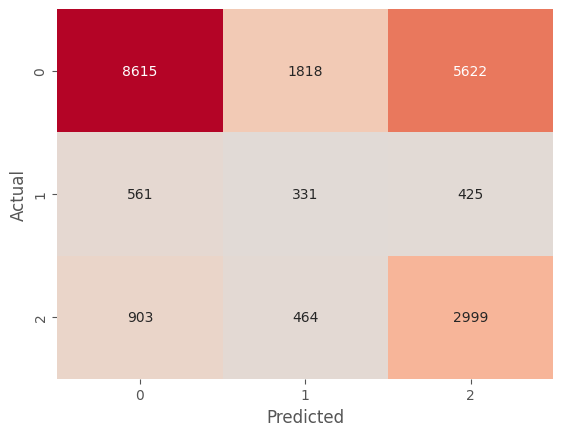

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = ['Clear(0)', 'Rain (1)', 'Snow (2)']

for col in target_col:
    model = models[col]
    y_pred = model.predict(X_val)

    print(f"Classification report for model_{col}")
    print(classification_report(y_true= y_val[col], y_pred= y_pred, target_names= class_names,
                                zero_division= 0))
    
    cm = confusion_matrix(y_true= y_val[col], y_pred= y_pred)

    sns.heatmap(cm, cmap = 'coolwarm', annot = True,
                center = 0, cbar = False, fmt = 'd')
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()




Classification report for model_target_3h
              precision    recall  f1-score   support

    Clear(0)       0.85      0.62      0.72     11242
    Rain (1)       0.37      0.55      0.44      1431
    Snow (2)       0.50      0.73      0.59      5109

    accuracy                           0.64     17782
   macro avg       0.57      0.63      0.58     17782
weighted avg       0.71      0.64      0.66     17782



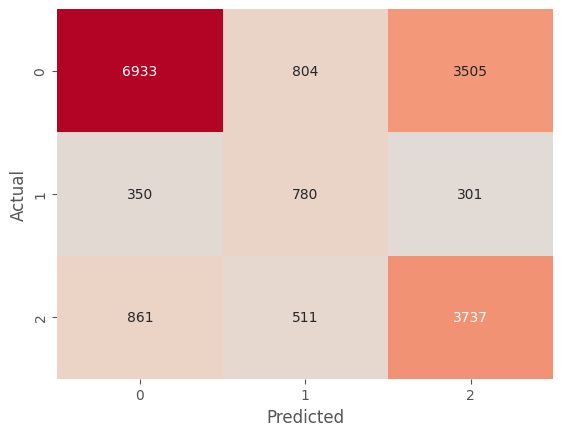

Classification report for model_target_6h
              precision    recall  f1-score   support

    Clear(0)       0.81      0.51      0.62     11238
    Rain (1)       0.30      0.44      0.35      1431
    Snow (2)       0.44      0.73      0.55      5113

    accuracy                           0.57     17782
   macro avg       0.51      0.56      0.51     17782
weighted avg       0.66      0.57      0.58     17782



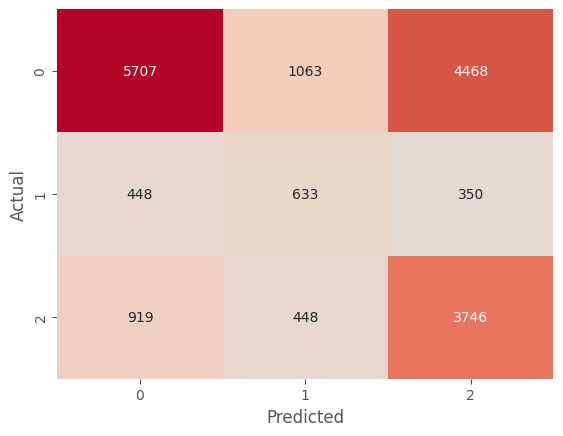

Classification report for model_target_12h
              precision    recall  f1-score   support

    Clear(0)       0.76      0.36      0.49     11235
    Rain (1)       0.20      0.37      0.26      1431
    Snow (2)       0.40      0.77      0.52      5116

    accuracy                           0.48     17782
   macro avg       0.45      0.50      0.42     17782
weighted avg       0.61      0.48      0.48     17782



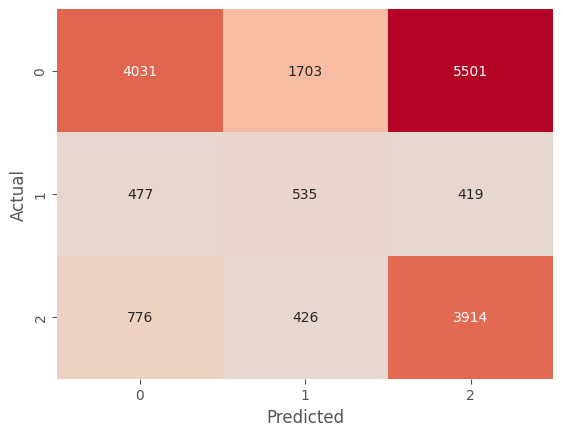

In [21]:

for col in target_col:
    model = models[col]
    y_pred = model.predict(X_test)

    print(f"Classification report for model_{col}")
    print(classification_report(y_true= y_test[col], y_pred= y_pred, target_names= class_names,
                                zero_division= 0))
    
    cm = confusion_matrix(y_true= y_test[col], y_pred= y_pred)

    sns.heatmap(cm, cmap = 'coolwarm', annot = True,
                center = 0, cbar = False, fmt = 'd')
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()




In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

for col, model in models.items():
    model_path = f"models/code_model_{col}.joblib"
    joblib.dump(model, model_path)
    print(f"✅ Saved: {model_path}")




✅ Saved: models/code_model_target_3h.joblib
✅ Saved: models/code_model_target_6h.joblib
✅ Saved: models/code_model_target_12h.joblib
